# Getting Started with OpenCV and Computer Vision

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
img = cv2.imread("./Images/fruit.png")

cv2.imshow("Fruit Image", img)

cv2.waitKey(0)          # hold window open until key press
cv2.destroyAllWindows() # clean up

QFontDatabase: Cannot find font directory /home/waseem/miniconda3/envs/cv_env/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/waseem/miniconda3/envs/cv_env/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/waseem/miniconda3/envs/cv_env/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/waseem/miniconda3/envs/cv_env/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Canno

#### *`Work with Numpy Matplotlib and OpenCV all together`*

- *`Stage 1 — Create Images from Scratch with NumPy:`* Before loading any real image, let's build images manually so you see exactly what's happening.

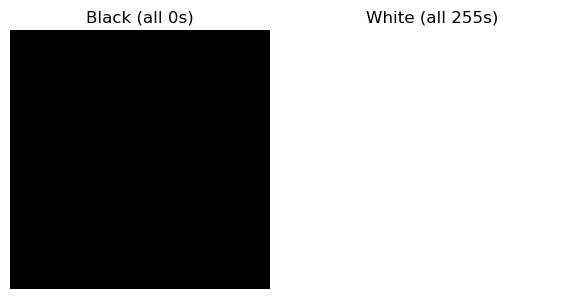

In [ ]:
black = np.zeros((200, 200), dtype=np.uint8)
white = np.ones((200, 200), dtype=np.uint8) * 255

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# vmin=0: Maps the value 0 to absolute black
# vmax=255: Maps the value 255 to absolute white
# This ensures 0 actually looks black even if there are no other values in the array
axes[0].imshow(black, cmap="gray", vmin=0, vmax=255) 
axes[0].set_title("Black (all 0s)")
axes[0].axis("off")

# We keep the same vmin/vmax here so the "white" array is compared 
# against the same 0-255 scale as the "black" array
axes[1].imshow(white, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("White (all 255s)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


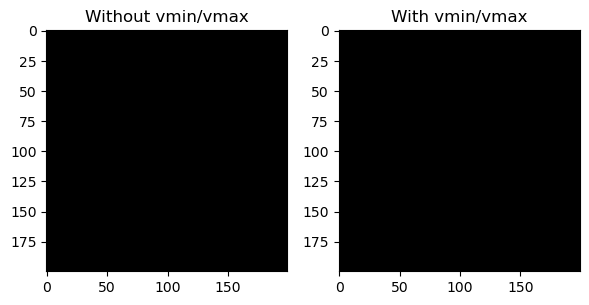

In [11]:
# What happens WITHOUT vmin/vmax on a black image?
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(black, cmap='gray')              # no vmin/vmax
axes[0].set_title("Without vmin/vmax")

axes[1].imshow(black, cmap='gray', vmin=0, vmax=255)  # with vmin/vmax
axes[1].set_title("With vmin/vmax")

plt.tight_layout()
plt.show()

# You'll see: left looks weird, right looks correct black

Shape: (200, 400)
Dtype: uint8
Min: 0 Max: 255


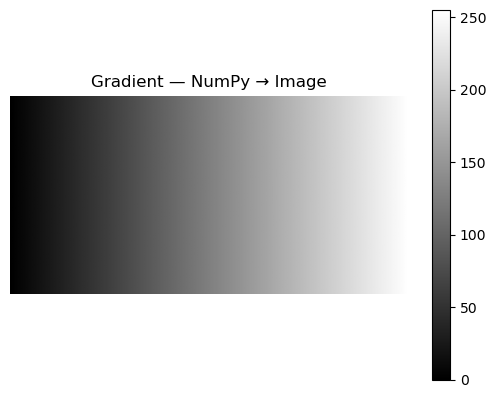

In [14]:
# np.linspace gives evenly spaced values → perfect for a gradient
row = np.linspace(0, 255, 400, dtype=np.uint8)  # 1D: 400 values 0→255

# Stack same row 200 times to make a 2D image
gradient = np.tile(row, (200, 1))  # shape → (200, 400)

print("Shape:", gradient.shape)    # (200, 400)
print("Dtype:", gradient.dtype)    # uint8
print("Min:", gradient.min(), "Max:", gradient.max())

plt.imshow(gradient, cmap='gray', vmin=0, vmax=255)
plt.title("Gradient — NumPy → Image")
plt.axis('off')
plt.colorbar()   # shows intensity scale
plt.show()

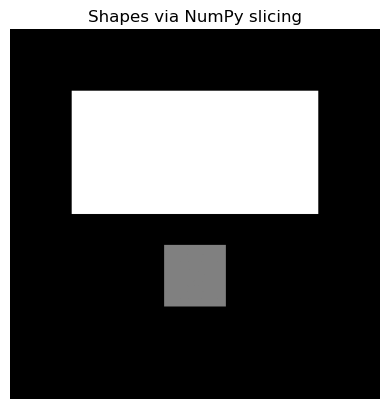

In [16]:
# Start with black canvas
canvas = np.zeros((300, 300), dtype=np.uint8)

# Draw a white rectangle using array slicing
# canvas[y1:y2, x1:x2] = value  ← remember: rows first (y), cols second (x)
canvas[50:150, 50:250] = 255      # white rectangle
canvas[175:225, 125:175] = 128    # gray square

plt.imshow(canvas, cmap='gray', vmin=0, vmax=255)
plt.title("Shapes via NumPy slicing")
plt.axis('off')
plt.show()

Shape: (200, 300, 3)
Dtype: uint8


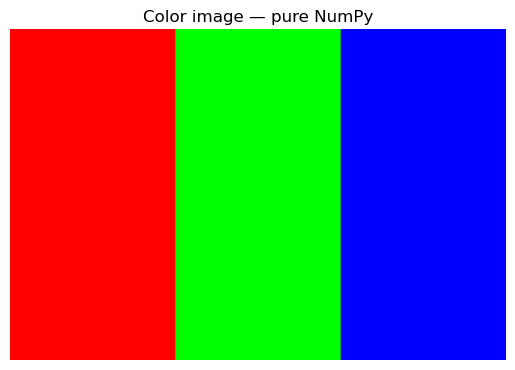

In [17]:
# 3D array → shape (H, W, 3)
# Last dimension = [R, G, B] for matplotlib
color_img = np.zeros((200, 300, 3), dtype=np.uint8)

print("Shape:", color_img.shape)   # (200, 300, 3)
print("Dtype:", color_img.dtype)   # uint8

# Paint regions with color using slicing
color_img[0:200,   0:100]  = [255, 0,   0]   # Red region
color_img[0:200, 100:200]  = [0,   255, 0]   # Green region
color_img[0:200, 200:300]  = [0,   0, 255]   # Blue region

plt.imshow(color_img)   # no cmap needed for color!
plt.title("Color image — pure NumPy")
plt.axis('off')
plt.show()

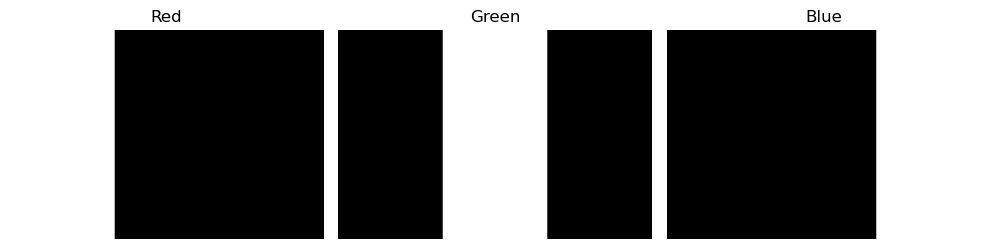

In [18]:
# Split into 3 separate 2D arrays
r_channel = color_img[:, :, 0]   # shape (200, 300)
g_channel = color_img[:, :, 1]
b_channel = color_img[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, ch, title in zip(axes,
                          [r_channel, g_channel, b_channel],
                          ["Red", "Green", "Blue"]):
    ax.imshow(ch, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

<class 'numpy.ndarray'>
(3264, 4928, 3)
uint8


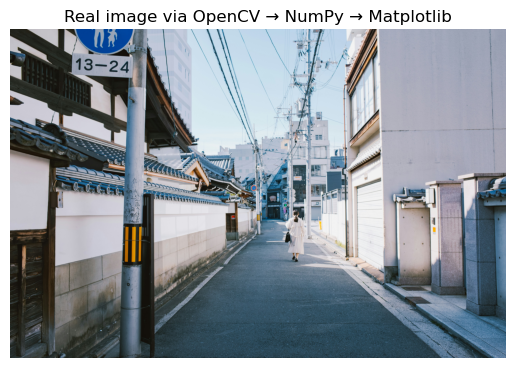

In [27]:
# Step 1: OpenCV loads image → immediately becomes a NumPy array
img_bgr = cv2.imread("./Images/japan_street.jpg")

# Step 2: Verify it's just a NumPy array
print(type(img_bgr))        # <class 'numpy.ndarray'>
print(img_bgr.shape)        # (512, 512, 3)
print(img_bgr.dtype)        # uint8

# Step 3: OpenCV = BGR, Matplotlib = RGB → must convert
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# # Step 4: Matplotlib displays it
plt.imshow(img_rgb)
plt.title("Real image via OpenCV → NumPy → Matplotlib")
plt.axis('off')
plt.show()

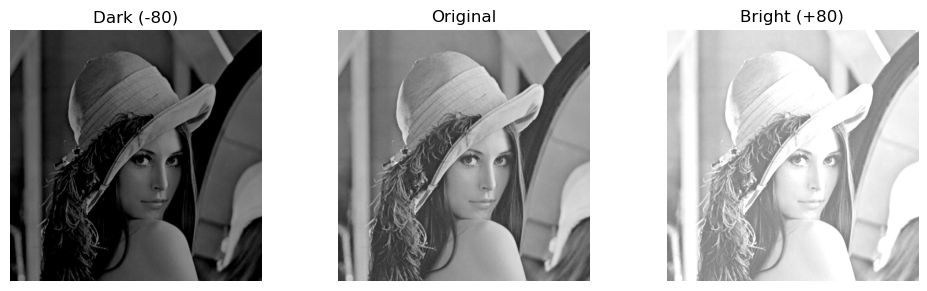

In [33]:
img_gray = cv2.imread("./Images/lena.png", cv2.IMREAD_GRAYSCALE)

# You use + 80 and - 80 to change the exposure of the image:

#     + 80 (Brighten): You are increasing the intensity of every pixel. If a pixel was 100 (dark gray), it becomes 180 (light gray).
#     - 80 (Darken): You are decreasing the intensity. If a pixel was 100, it becomes 20 (almost black).

bright = np.clip(img_gray.astype(np.int16) + 80, 0, 255).astype(np.uint8)
dark   = np.clip(img_gray.astype(np.int16) - 80, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for ax, image, title in zip(axes,
                              [dark, img_gray, bright],
                              ["Dark (-80)", "Original", "Bright (+80)"]):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')

# tight_layout() calculates the best spacing so that titles, labels, and the images themselves don't overlap and fit neatly within the figure window.
plt.tight_layout()
plt.show()